In [1]:
import pandas as pd
import numpy as np 

In [ ]:
df=pd.read_csv("train_transaction.csv")

In [3]:
df.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
df.isnull().sum().sum()

np.int64(95566686)

In [5]:
df['isFraud'].value_counts()

isFraud
0    569877
1     20663
Name: count, dtype: int64

In [6]:
df.tail()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
590535,3577535,0,15811047,49.00,W,6550,NaN,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
590536,3577536,0,15811049,39.50,W,10444,225.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
590537,3577537,0,15811079,30.95,W,12037,595.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
590538,3577538,0,15811088,117.00,W,7826,481.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
590539,3577539,0,15811131,279.95,W,15066,170.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
bins = list(range(0, 101, 10))  # [0, 10, 20, ..., 100]

# Cut the transaction amounts into intervals
df['interval'] = pd.cut(df['TransactionAmt'], bins=bins, right=False)

# Count values in each interval
interval_counts = df['interval'].value_counts().sort_index()

# Count values greater than 100
greater_than_100 = (df['TransactionAmt'] > 100).sum()

print("Counts per interval (0–10, 10–20, ... up to 100):")
print(interval_counts)
print("\nNumber of values greater than 100:", greater_than_100)


Counts per interval (0–10, 10–20, ... up to 100):
interval
[0, 10)       6795
[10, 20)     20359
[20, 30)     53477
[30, 40)     58365
[40, 50)     48519
[50, 60)     94568
[60, 70)     14955
[70, 80)     21347
[80, 90)     15778
[90, 100)    14094
Name: count, dtype: int64

Number of values greater than 100: 221921


In [8]:
unique_cards = df['card4'].unique()
print("Unique card types:", unique_cards)

# Get total number of unique values
total_unique = df['card4'].nunique()
print("Total unique card types:", total_unique)

# Get count of each card type
card_counts = df['card4'].value_counts()
print("\nCounts of each card type:")
print(card_counts)

Unique card types: ['discover' 'mastercard' 'visa' 'american express' nan]
Total unique card types: 4

Counts of each card type:
card4
visa                384767
mastercard          189217
american express      8328
discover              6651
Name: count, dtype: int64


In [9]:
df = df[df['TransactionAmt'] <= 100]
print("Remaining rows:", len(df))

Remaining rows: 368619


In [10]:
# Drop rows where card4 == 'american express'
df = df[df['card4'] != 'american express']

print("Remaining rows:", len(df))

Remaining rows: 364615


In [11]:
unique_id = df['P_emaildomain'].unique()
print("Unique id:", unique_id)

# Get total number of unique values
total_unique_id = df['P_emaildomain'].nunique()
print("Total unique id types:", total_unique_id)

# Get count of each card type
id_counts = df['P_emaildomain'].value_counts()
print("\nCounts of each id type:")
print(id_counts)

Unique id: [nan 'gmail.com' 'outlook.com' 'yahoo.com' 'anonymous.com' 'hotmail.com'
 'verizon.net' 'aol.com' 'comcast.net' 'charter.net' 'rocketmail.com'
 'me.com' 'optonline.net' 'icloud.com' 'live.com.mx' 'gmail' 'live.com'
 'ymail.com' 'sbcglobal.net' 'juno.com' 'bellsouth.net' 'att.net'
 'msn.com' 'q.com' 'cox.net' 'yahoo.com.mx' 'servicios-ta.com'
 'hotmail.es' 'cfl.rr.com' 'centurylink.net' 'gmx.de' 'frontiernet.net'
 'windstream.net' 'mail.com' 'frontier.com' 'outlook.es' 'roadrunner.com'
 'mac.com' 'prodigy.net.mx' 'earthlink.net' 'web.de' 'aim.com'
 'netzero.com' 'embarqmail.com' 'cableone.net' 'twc.com' 'yahoo.fr'
 'yahoo.de' 'yahoo.es' 'sc.rr.com' 'live.fr' 'yahoo.co.uk'
 'suddenlink.net' 'netzero.net' 'hotmail.fr' 'hotmail.de' 'hotmail.co.uk'
 'ptd.net' 'protonmail.com' 'yahoo.co.jp']
Total unique id types: 59

Counts of each id type:
P_emaildomain
gmail.com           146924
yahoo.com            59284
hotmail.com          33723
anonymous.com        19271
aol.com            

In [12]:
# List of domains not operable in India
not_in_india = [
    'comcast.net', 'sbcglobal.net', 'bellsouth.net', 'cox.net', 'optonline.net',
    'charter.net', 'earthlink.net', 'frontier.com', 'windstream.net',
    'roadrunner.com', 'netzero.com', 'netzero.net', 'cfl.rr.com', 'twc.com',
    'cableone.net', 'suddenlink.net', 'q.com', 'sc.rr.com', 'centurylink.net',
    'ptd.net'
]

# Drop rows where P_emaildomain is in the list
df = df[~df['P_emaildomain'].isin(not_in_india)]

print("Remaining rows after dropping non‑India domains:", len(df))


Remaining rows after dropping non‑India domains: 355523


In [13]:
total_values = df['R_emaildomain'].count()
print("Total non-missing values in R_emaildomain:", total_values)

Total non-missing values in R_emaildomain: 101922


In [14]:
df.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V331,V332,V333,V334,V335,V336,V337,V338,V339,interval
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[60, 70)"
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[20, 30)"
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[50, 60)"
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[50, 60)"
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"[50, 60)"


In [15]:
print("Dataframe shape:", df.shape)

Dataframe shape: (355523, 395)


In [16]:
missing_summary = df.isnull().sum().sort_values(ascending=False)
print(missing_summary.head(20))  # top 20 columns with most missing values

dist2    324228
D7       321700
V155     306608
V154     306608
V147     306608
V148     306608
V149     306608
V142     306608
V141     306608
V153     306608
V146     306608
V156     306608
V157     306608
V158     306608
V140     306608
V139     306608
V161     306608
V162     306608
V163     306608
V138     306608
dtype: int64


In [17]:
import pandas as pd

# Example: list of columns you want to drop
cols_to_drop = [
    'dist2', 'D7', 'V155', 'V154', 'V147', 'V148', 'V149',
    'V142', 'V141', 'V153', 'V146', 'V156', 'V157', 'V158',
    'V140', 'V139', 'V161', 'V162', 'V163', 'V138'
]

# Drop these columns from df
df = df.drop(columns=cols_to_drop)

print("Remaining columns:", df.shape[1])
print("Dataframe shape:", df.shape)

Remaining columns: 375
Dataframe shape: (355523, 375)


In [18]:
# Keep 20% of the dataset randomly
df_sample = df.sample(frac=0.2, random_state=42)

print("Original rows:", len(df))
print("Sampled rows:", len(df_sample))


Original rows: 355523
Sampled rows: 71105


In [19]:

threshold = 0.8 * len(df)
df_reduced = df.dropna(axis=1, thresh=threshold)

print("Remaining columns after dropping high-missing:", df_reduced.shape[1])

Remaining columns after dropping high-missing: 183


In [20]:
print("Dataframe shape:", df_sample.shape)
print("Dataframe shape:", df_reduced.shape)

Dataframe shape: (71105, 375)
Dataframe shape: (355523, 183)


In [21]:
from sklearn.feature_selection import VarianceThreshold


selector = VarianceThreshold(threshold=0.01)  
df_numeric = df_reduced.select_dtypes(include=['number'])  # only numeric columns
df_selected = selector.fit_transform(df_numeric)

print("Remaining numeric features:", df_selected.shape[1])

Remaining numeric features: 158


In [22]:
# Step 1: Drop high-missing columns
threshold = 0.8 * len(df)
df_reduced = df.dropna(axis=1, thresh=threshold)

# Step 2: Drop low-variance numeric columns
from sklearn.feature_selection import VarianceThreshold
selector = VarianceThreshold(threshold=0.01)
df_numeric = df_reduced.select_dtypes(include=['number'])
df_selected = selector.fit_transform(df_numeric)

# Step 3: Sample rows
df_final = df_reduced.sample(frac=0.2, random_state=42)

print("Final dataset shape:", df_final.shape)

Final dataset shape: (71105, 183)


In [23]:
df_final = df_final.drop(columns=['interval'], errors='ignore')

In [24]:
X = df_final.drop('isFraud', axis=1)
y = df_final['isFraud']

In [25]:
from sklearn.impute import SimpleImputer

num_cols = X.select_dtypes(include=['number']).columns
cat_cols = X.select_dtypes(include=['object']).columns

imputer_num = SimpleImputer(strategy='median')
X[num_cols] = imputer_num.fit_transform(X[num_cols])

imputer_cat = SimpleImputer(strategy='most_frequent')
X[cat_cols] = imputer_cat.fit_transform(X[cat_cols])

In [26]:
from sklearn.preprocessing import LabelEncoder

for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [28]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [29]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99     13721
           1       0.89      0.34      0.49       500

    accuracy                           0.98     14221
   macro avg       0.94      0.67      0.74     14221
weighted avg       0.97      0.98      0.97     14221



In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Increase weight for fraud class (1)
model2 = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight={0:1, 1:10}   # tune ratio based on imbalance
)

# Train
model2.fit(X_train, y_train)

# Predict
y_pred2 = model2.predict(X_test)

# Evaluate
print(classification_report(y_test, y_pred2))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99     13721
           1       0.90      0.34      0.49       500

    accuracy                           0.98     14221
   macro avg       0.94      0.67      0.74     14221
weighted avg       0.97      0.98      0.97     14221



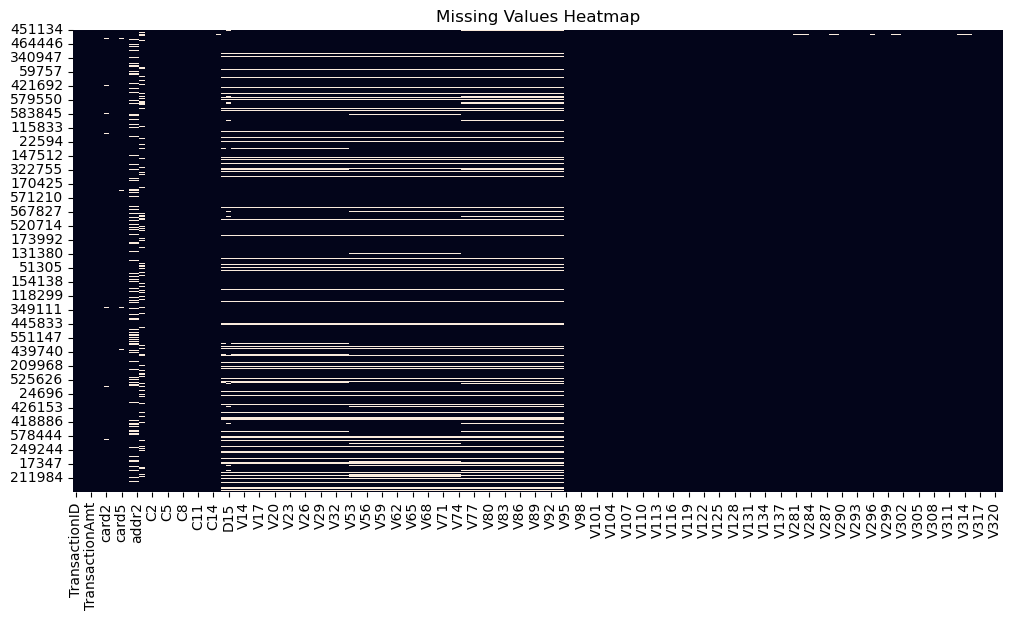

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.heatmap(df_final.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

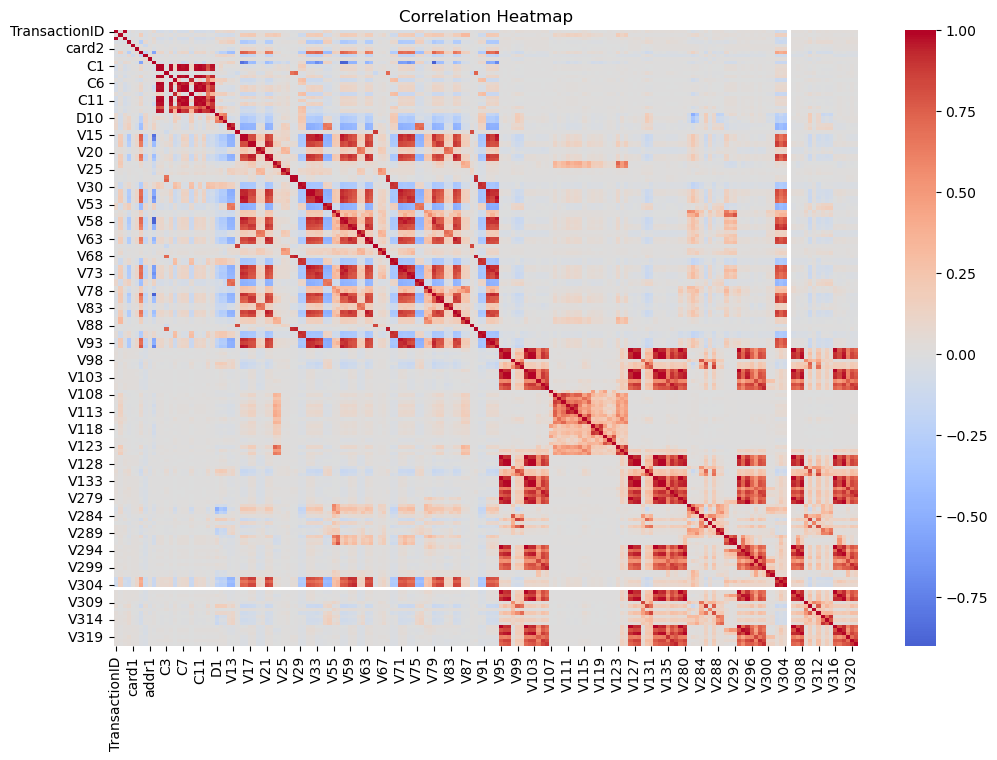

In [32]:
plt.figure(figsize=(12,8))
corr = df_final.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

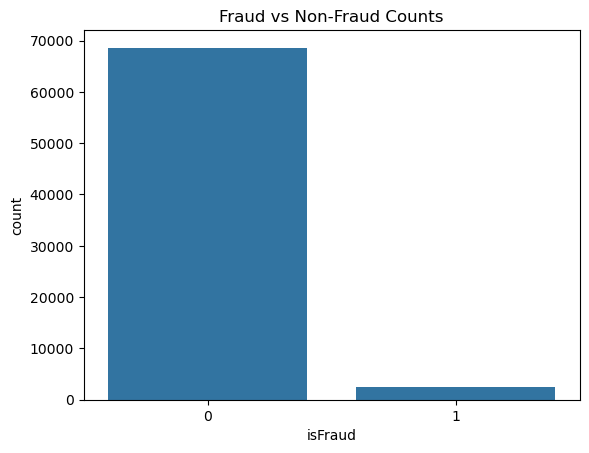

In [33]:
sns.countplot(x='isFraud', data=df_final)
plt.title("Fraud vs Non-Fraud Counts")
plt.show()

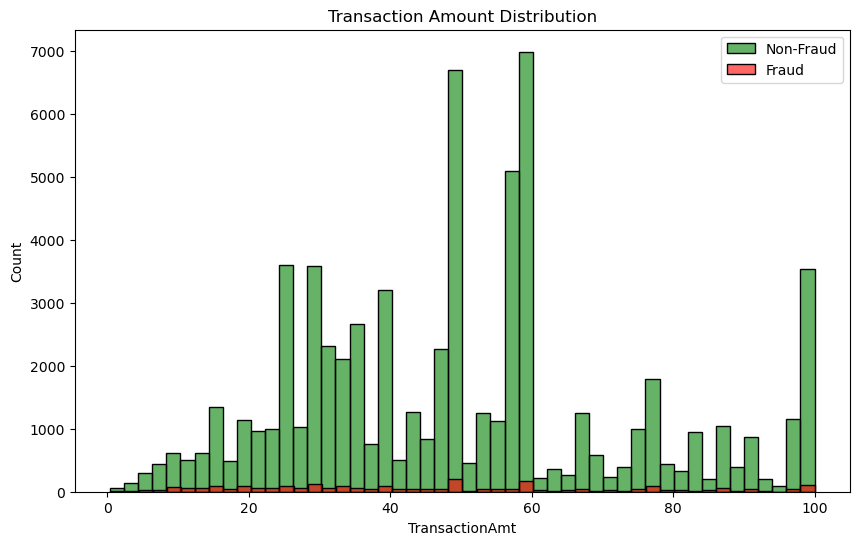

In [34]:
plt.figure(figsize=(10,6))
sns.histplot(df_final[df_final['isFraud']==0]['TransactionAmt'], bins=50, color='green', label='Non-Fraud', alpha=0.6)
sns.histplot(df_final[df_final['isFraud']==1]['TransactionAmt'], bins=50, color='red', label='Fraud', alpha=0.6)
plt.legend()
plt.title("Transaction Amount Distribution")
plt.show()

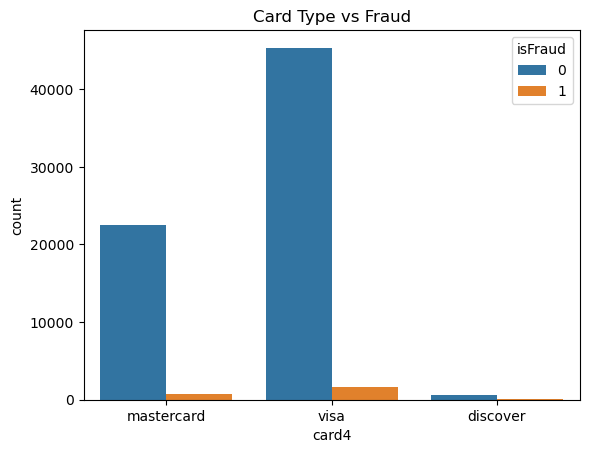

In [35]:
sns.countplot(x='card4', hue='isFraud', data=df_final)
plt.title("Card Type vs Fraud")
plt.show()

In [ ]:
df_final['Transaction_hour'] = (df_final['TransactionDT'] / 3600) % 24
sns.countplot(x='Transaction_hour', hue='isFraud', data=df_final)
plt.title("Fraud by Transaction Hour")
plt.show()

C:\Users\Animesh Yadav\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


Fraud count: 0
Non-fraud count: 0
Balanced dataset shape: (0, 365)
